In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import torch as tch
import torch.nn as nn
import torch.optim as optim

tch.cuda.is_available()


True

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data_bank = pd.read_csv('bank.csv')
data_bank["default"]=data_bank["default"].map({"no":0,"yes":1})
data_bank["housing"]=data_bank["housing"].map({"no":0,"yes":1})
data_bank["loan"]=data_bank["loan"].map({"no":0,"yes":1})
data_bank["deposit"]=data_bank["deposit"].map({"no":0,"yes":1})
edu_map = {"unknown":0,
           "primary":1,
           "secondary":2,
           "tertiary":3}
data_bank["education"]=data_bank["education"].map(edu_map)
data_bank = pd.get_dummies(data_bank, columns=['education'], dtype=int)
month_map = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

# 1. Переводим строки в числа 1-12
data_bank['month_num'] = data_bank['month'].map(month_map)

# 2. Создаем циклические признаки
# 2 * pi / 12 — это полный круг (12 месяцев)
data_bank['month_sin'] = np.sin(2 * np.pi * data_bank['month_num'] / 12)
data_bank['month_cos'] = np.cos(2 * np.pi * data_bank['month_num'] / 12)

# Теперь можно удалить исходную колонку и промежуточную month_num
data_bank = data_bank.drop(['month', 'month_num'], axis=1)
data_bank = pd.get_dummies(data_bank, columns=['poutcome'], dtype=int)
data_bank = pd.get_dummies(data_bank, columns=['contact'], dtype=int)
data_bank = pd.get_dummies(data_bank, columns=['marital'], dtype=int)
data_bank = pd.get_dummies(data_bank, columns=['job'], dtype=int)

y = data_bank['deposit']
X = data_bank.drop('deposit', axis=1)

X_train, X_test, y_bank_train, y_bank_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_bank_train = scaler.fit_transform(X_train)
X_bank_test = scaler.transform(X_test)


In [23]:
class MLPClassifier(nn.Module):
    def __init__(self, input_size, hidden_sizes=[64, 32, 16], dropout_rate=0.3):
        super(MLPClassifier, self).__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, 1)) # 1 это зависит от классов сколько вариантов ответов  столько и ставиться 
        layers.append(nn.Sigmoid())

        self.networks = nn.Sequential(*layers)

    def forward(self, x):
        return self.networks(x)
    

In [24]:
# Тензоры
X_bank_train_tensor = tch.FloatTensor(X_bank_train)
y_bank_train_tensor = tch.FloatTensor(y_bank_train.values).reshape(-1, 1)
X_bank_test_tensor = tch.FloatTensor(X_bank_test)
y_bank_test_tensor = tch.FloatTensor(y_bank_test.values).reshape(-1, 1)

# DataLoader
bank_train_dataset = tch.utils.data.TensorDataset(X_bank_train_tensor, y_bank_train_tensor)
bank_train_loader = tch.utils.data.DataLoader(bank_train_dataset, batch_size=64, shuffle=True)

In [25]:
input_size_bank = X_bank_train.shape[1]
model_transfer = MLPClassifier(input_size=input_size_bank)

In [59]:
# ============================================================================
# ПОДГРУЗКА ПРЕДОБУЧЕННЫХ ВЕСОВ
# ============================================================================
pretrained_path = 'adult_pretrained1.pth'

try:
    # 1. Загружаем state_dict из файла
    pretrained_dict = tch.load(pretrained_path, map_location=tch.device('cuda'), weights_only=True)
    model_dict = model_transfer.state_dict()
    # 2. Если в файле сохранена вся модель, извлекаем только веса
    if isinstance(pretrained_dict, dict) and 'state_dict' in pretrained_dict:
        pretrained_dict = pretrained_dict['state_dict']
    
    # 3. Получаем текущие веса модели
    
    
    # 4. Фильтруем веса (на случай несовпадения имен или размеров слоёв)
    pretrained_dict = {k: v for k, v in pretrained_dict.items() 
                       if k in model_dict and v.shape == model_dict[k].shape}
    
    missing = [k for k in model_dict.keys() if k not in pretrained_dict]
    if missing:
        print(f"Отсутствующие ключи: {missing}")  # покажем первые 5
    
    # 5. Обновляем веса модели
    model_dict.update(pretrained_dict)
    model_transfer.load_state_dict(model_dict, strict=False)
    
    print(f"✅ Веса успешно загружены из {pretrained_path}")
    print(f"📦 Загружено {len(pretrained_dict)} параметра")
    
except FileNotFoundError:
    print(f"❌ Файл {pretrained_path} не найден!")
except Exception as e:
    print(f"❌ Ошибка при загрузке весов: {e}")
# Проверка загрузки весов
print("=== Проверка загрузки весов ===")
for name, param in model_transfer.named_parameters():
    if 'networks.0' in name:  # Первый слой
        print(f"{name}: mean={param.mean().item():.4f}, std={param.std().item():.4f}")

print("=== Детальная статистика загруженных весов ===")
total_loaded_weights = 0
for name, param in model_transfer.named_parameters():
    num_weights = param.numel()
    total_loaded_weights += num_weights
    print(f"{name}: {num_weights} весов, mean={param.mean().item():.4f}, std={param.std().item():.4f}")

print(f"\n📊 ВСЕГО отдельных весовых значений: {total_loaded_weights}")

Отсутствующие ключи: ['networks.0.weight']
✅ Веса успешно загружены из adult_pretrained1.pth
📦 Загружено 22 параметра
=== Проверка загрузки весов ===
networks.0.weight: mean=-0.0027, std=0.1078
networks.0.bias: mean=0.0248, std=0.0728
=== Детальная статистика загруженных весов ===
networks.0.weight: 2432 весов, mean=-0.0027, std=0.1078
networks.0.bias: 64 весов, mean=0.0248, std=0.0728
networks.1.weight: 64 весов, mean=0.9818, std=0.0895
networks.1.bias: 64 весов, mean=-0.1738, std=0.1562
networks.4.weight: 2048 весов, mean=-0.0274, std=0.1367
networks.4.bias: 32 весов, mean=-0.0050, std=0.0760
networks.5.weight: 32 весов, mean=0.9691, std=0.0722
networks.5.bias: 32 весов, mean=-0.1564, std=0.2200
networks.8.weight: 512 весов, mean=0.0132, std=0.1584
networks.8.bias: 16 весов, mean=0.0050, std=0.1044
networks.9.weight: 16 весов, mean=1.1875, std=0.1361
networks.9.bias: 16 весов, mean=0.2227, std=0.3781
networks.12.weight: 16 весов, mean=-0.1432, std=0.3449
networks.12.bias: 1 весов, me

C:\Users\1\AppData\Local\Temp\ipykernel_147208\190167487.py:47: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\ReduceOps.cpp:1823.)
  print(f"{name}: {num_weights} весов, mean={param.mean().item():.4f}, std={param.std().item():.4f}")


In [32]:
def freeze_layers(model, num_linear_to_freeze=0, freeze_bn=False):
    """
    Замораживает Linear слои + опционально BatchNorm
    
    Аргументы:
        num_linear_to_freeze (int): Сколько Linear слоёв заморозить (0-4)
        freeze_bn (bool): Замораживать ли BatchNorm вместе с Linear
    
    Примеры:
        freeze_layers(model, 0)           # Не замораживать ничего
        freeze_layers(model, 1)           # Заморозить 1 Linear
        freeze_layers(model, 1, True)     # Заморозить 1 Linear + BN
        freeze_layers(model, 4, True)     # Заморозить всё
    """
    linear_count = 0
    total_linear = 0
    
    # Считаем всего Linear слоёв
    for module in model.networks:
        if isinstance(module, nn.Linear):
            total_linear += 1
    
    print(f"📊 Всего Linear слоёв: {total_linear}")
    print(f"🔒 Планируем заморозить: {num_linear_to_freeze} Linear" + 
          (f" + BatchNorm" if freeze_bn else ""))
    print("-" * 50)
    
    # Проходим по всем модулям
    for i, module in enumerate(model.networks):
        
        # === Linear слои ===
        if isinstance(module, nn.Linear):
            if linear_count < num_linear_to_freeze:
                module.weight.requires_grad = False
                module.bias.requires_grad = False
                print(f"🔒 Linear #{linear_count+1}: {module.in_features}→{module.out_features}")
            else:
                module.weight.requires_grad = True
                module.bias.requires_grad = True
                print(f"🔓 Linear #{linear_count+1}: {module.in_features}→{module.out_features}")
            linear_count += 1
        
        # === BatchNorm слои ===
        elif isinstance(module, nn.BatchNorm1d):
            if freeze_bn and linear_count <= num_linear_to_freeze:
                module.weight.requires_grad = False
                module.bias.requires_grad = False
                module.eval()  # Важно для BN!
                print(f"🔒 BatchNorm (после Linear #{linear_count})")
            else:
                module.weight.requires_grad = True
                module.bias.requires_grad = True
                module.train()
                print(f"🔓 BatchNorm (после Linear #{linear_count})")
    
    print("-" * 50)
    print(f"✅ Заморожено: {num_linear_to_freeze}/{total_linear} Linear слоёв")
    if freeze_bn:
        print(f"✅ BatchNorm заморожен вместе с Linear")
    else:
        print(f"✅ BatchNorm остаётся обучаемым")

In [60]:
freeze_layers(model_transfer, num_linear_to_freeze=2, freeze_bn=True) 


optimizer_transfer = optim.Adam(
    filter(lambda p: p.requires_grad, model_transfer.parameters()),  # Важно!
    lr=0.0005  # Маленький learning rate для fine-tuning
)

# Функция потерь (для бинарной классификации)
criterion = nn.BCELoss()  # Или BCEWithLogitsLoss если нет Sigmoid

scheduler = optim.lr_scheduler.StepLR(optimizer_transfer, step_size=30, gamma=0.1)

# ============================================================================
# Цикл обучения (FINE-TUNING)
# ============================================================================
model_transfer.train()  # Режим обучения!
num_epochs = 50
transfer_losses = []
transfer_accuracies = []

print("\n🚀 Начинаем дообучение (Fine-Tuning)...\n")

for epoch in range(num_epochs):
    epoch_loss = 0
    correct = 0
    total = 0
    
    # Проход по всем батчам тренировочного датасета
    for batch_X, batch_y in bank_train_loader:
        
        # 1. Обнуляем градиенты
        optimizer_transfer.zero_grad()
        
        # 2. Прямой проход (Forward)
        outputs = model_transfer(batch_X)
        
        # 3. Считаем ошибку
        loss = criterion(outputs, batch_y)
        
        # 4. Обратный проход (Backward) - вычисляем градиенты
        loss.backward()
        
        # 5. Обновляем веса (только размороженные!)
        optimizer_transfer.step()
        
        # Считаем статистику
        epoch_loss += loss.item()
        predicted = (outputs >= 0.5).float()
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)
    
    # Средние метрики за эпоху
    scheduler.step()
    avg_loss = epoch_loss / len(bank_train_loader)
    accuracy = correct / total
    transfer_losses.append(avg_loss)
    transfer_accuracies.append(accuracy)
    
    # Вывод прогресса каждые 10 эпох
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}: Loss = {avg_loss:.4f} | Acc = {accuracy:.4f}')

# ============================================================================
# ШАГ 4: Оценка на тестовом датасете
# ============================================================================
model_transfer.eval()  # Режим тестирования!

with tch.no_grad():  # Не считаем градиенты
    test_outputs = model_transfer(X_bank_test_tensor)
    test_proba = test_outputs.numpy().flatten()
    test_classes = (test_outputs >= 0.5).float().numpy().flatten()

📊 Всего Linear слоёв: 4
🔒 Планируем заморозить: 2 Linear + BatchNorm
--------------------------------------------------
🔒 Linear #1: 38→64
🔒 BatchNorm (после Linear #1)
🔒 Linear #2: 64→32
🔒 BatchNorm (после Linear #2)
🔓 Linear #3: 32→16
🔓 BatchNorm (после Linear #3)
🔓 Linear #4: 16→1
--------------------------------------------------
✅ Заморожено: 2/4 Linear слоёв
✅ BatchNorm заморожен вместе с Linear

🚀 Начинаем дообучение (Fine-Tuning)...

Epoch 10/50: Loss = 0.6054 | Acc = 0.6907
Epoch 20/50: Loss = 0.5793 | Acc = 0.7066
Epoch 30/50: Loss = 0.5749 | Acc = 0.7123
Epoch 40/50: Loss = 0.5710 | Acc = 0.7060
Epoch 50/50: Loss = 0.5694 | Acc = 0.7172



📊 МЕТРИКИ НА ТЕСТЕ:
------------------------------
Accuracy       : 0.7712
Precision      : 0.7563
Recall         : 0.7628
F1-Score       : 0.7595
ROC-AUC        : 0.8418
PR-AUC (AP)    : 0.8032
------------------------------


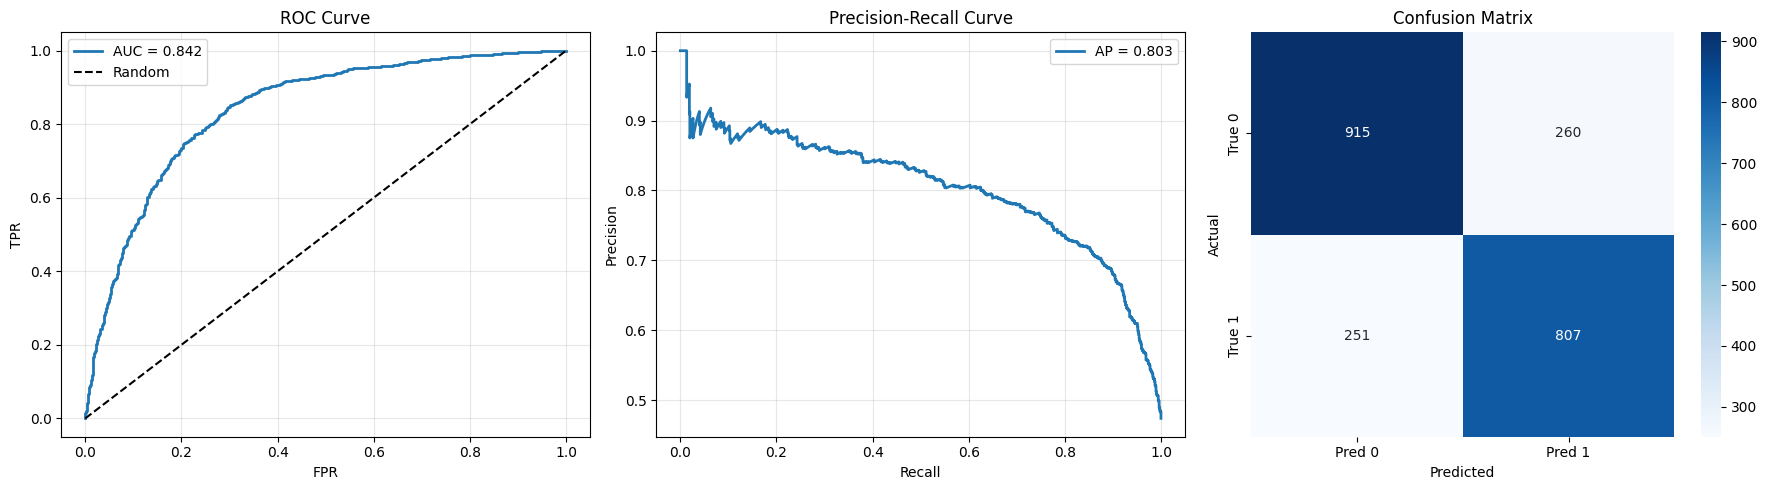

In [61]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             roc_auc_score, f1_score, average_precision_score,
                             roc_curve, precision_recall_curve, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Считаем все метрики
metrics = {
    'Accuracy': accuracy_score(y_bank_test, test_classes),
    'Precision': precision_score(y_bank_test, test_classes),
    'Recall': recall_score(y_bank_test, test_classes),
    'F1-Score': f1_score(y_bank_test, test_classes),
    'ROC-AUC': roc_auc_score(y_bank_test, test_proba),
    'PR-AUC (AP)': average_precision_score(y_bank_test, test_proba)
}

# 2. Вывод метрик
print("\n📊 МЕТРИКИ НА ТЕСТЕ:")
print("-" * 30)
for name, value in metrics.items():
    print(f"{name:15s}: {value:.4f}")
print("-" * 30)

# 3. Графики
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: ROC Curve
fpr, tpr, _ = roc_curve(y_bank_test, test_proba)
axes[0].plot(fpr, tpr, label=f"AUC = {metrics['ROC-AUC']:.3f}", linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

# График 2: PR Curve
precisions, recalls, _ = precision_recall_curve(y_bank_test, test_proba)
axes[1].plot(recalls, precisions, label=f"AP = {metrics['PR-AUC (AP)']:.3f}", linewidth=2)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(); axes[1].grid(alpha=0.3)

# График 3: Confusion Matrix
cm = confusion_matrix(y_bank_test, test_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], 
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()



🔬 ТЕСТИРОВАНИЕ: ЗАМОРОЗКА 0 СЛОЁВ
✅ Веса загружены: 22 параметров
📊 Всего Linear слоёв: 4
🔒 Планируем заморозить: 0 Linear + BatchNorm
--------------------------------------------------
🔓 Linear #1: 38→64
🔓 BatchNorm (после Linear #1)
🔓 Linear #2: 64→32
🔓 BatchNorm (после Linear #2)
🔓 Linear #3: 32→16
🔓 BatchNorm (после Linear #3)
🔓 Linear #4: 16→1
--------------------------------------------------
✅ Заморожено: 0/4 Linear слоёв
✅ BatchNorm заморожен вместе с Linear
  Epoch 10/50: Loss = 0.4463 | Acc = 0.8013
  Epoch 20/50: Loss = 0.4122 | Acc = 0.8167
  Epoch 30/50: Loss = 0.3956 | Acc = 0.8273
  Epoch 40/50: Loss = 0.3900 | Acc = 0.8297
  Epoch 50/50: Loss = 0.3871 | Acc = 0.8346

📊 МЕТРИКИ НА ТЕСТЕ:
  Accuracy:  0.8307
  Precision: 0.7951
  Recall:    0.8658
  F1-Score:  0.8290
  ROC-AUC:   0.9078

🔬 ТЕСТИРОВАНИЕ: ЗАМОРОЗКА 1 СЛОЁВ
✅ Веса загружены: 22 параметров
📊 Всего Linear слоёв: 4
🔒 Планируем заморозить: 1 Linear + BatchNorm
--------------------------------------------------


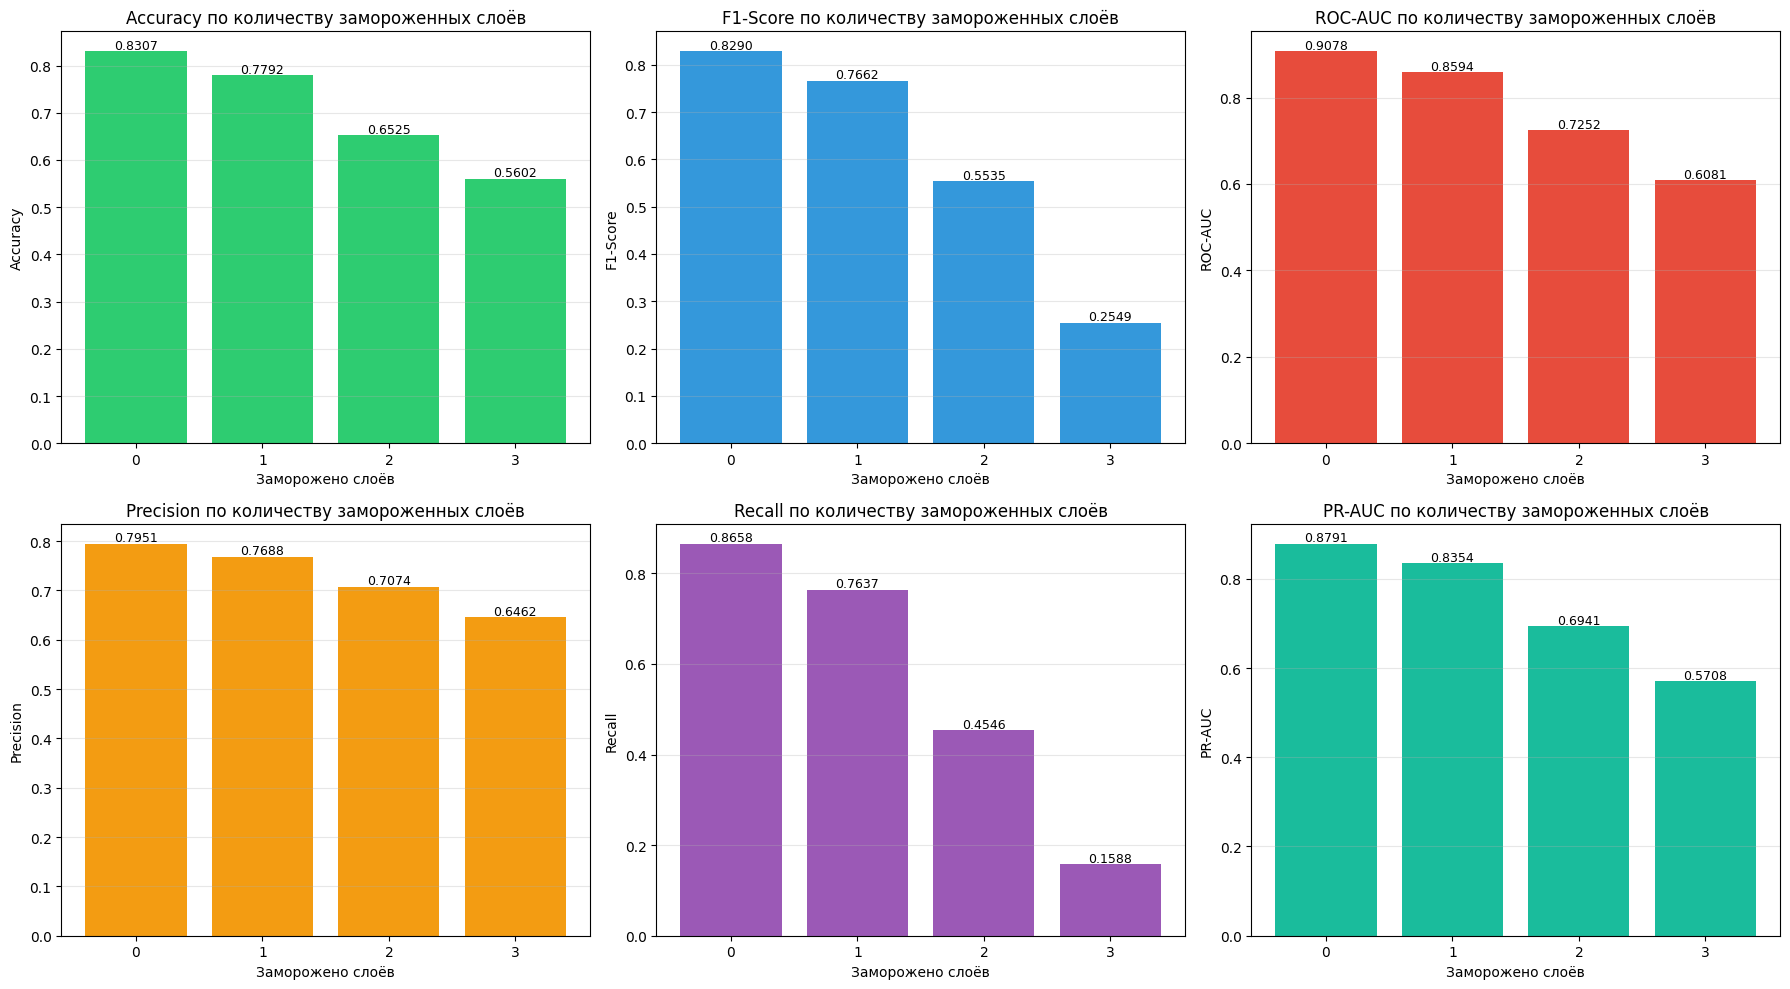


🏆 ЛУЧШИЙ РЕЗУЛЬТАТ: 0 замороженных слоёв
   ROC-AUC: 0.9078
   Accuracy: 0.8307


In [63]:
# ============================================================================
# МАССОВОЕ ТЕСТИРОВАНИЕ РАЗНЫХ УРОВНЕЙ ЗАМОРОЗКИ
# ============================================================================
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             roc_auc_score, f1_score, average_precision_score)
import pandas as pd

# Результаты для всех конфигураций
results = []

# Тестируем заморозку 0, 1, 2, 3 слоёв
for num_freeze in [0, 1, 2, 3]:
    print(f"\n{'='*60}")
    print(f"🔬 ТЕСТИРОВАНИЕ: ЗАМОРОЗКА {num_freeze} СЛОЁВ")
    print(f"{'='*60}")
    
    # 1. Создаём новую модель для каждого теста
    input_size_bank = X_bank_train.shape[1]
    model_test = MLPClassifier(input_size=input_size_bank)
    
    # 2. Загружаем предобученные веса
    pretrained_path = 'adult_pretrained1.pth'
    try:
        pretrained_dict = tch.load(pretrained_path, map_location=tch.device('cpu'), weights_only=True)
        model_dict = model_test.state_dict()
        pretrained_dict = {k: v for k, v in pretrained_dict.items() 
                           if k in model_dict and v.shape == model_dict[k].shape}
        model_dict.update(pretrained_dict)
        model_test.load_state_dict(model_dict, strict=False)
        print(f"✅ Веса загружены: {len(pretrained_dict)} параметров")
    except:
        print("⚠️ Веса не загружены, обучаем с нуля")
    
    # 3. Замораживаем слои
    freeze_layers(model_test, num_linear_to_freeze=num_freeze, freeze_bn=True)
    
    # 4. Оптимизатор только для обучаемых параметров
    optimizer_test = optim.Adam(
        filter(lambda p: p.requires_grad, model_test.parameters()),
        lr=0.0005
    )
    scheduler_test = optim.lr_scheduler.StepLR(optimizer_test, step_size=30, gamma=0.1)
    criterion = nn.BCELoss()
    
    # 5. Обучение
    model_test.train()
    num_epochs = 50
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        correct = 0
        total = 0
        
        for batch_X, batch_y in bank_train_loader:
            optimizer_test.zero_grad()
            outputs = model_test(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer_test.step()
            
            epoch_loss += loss.item()
            predicted = (outputs >= 0.5).float()
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)
        
        scheduler_test.step()
        
        if (epoch + 1) % 10 == 0:
            avg_loss = epoch_loss / len(bank_train_loader)
            accuracy = correct / total
            print(f'  Epoch {epoch+1}/{num_epochs}: Loss = {avg_loss:.4f} | Acc = {accuracy:.4f}')
    
    # 6. Оценка на тесте
    model_test.eval()
    with tch.no_grad():
        test_outputs = model_test(X_bank_test_tensor)
        test_proba = test_outputs.numpy().flatten()
        test_classes = (test_outputs >= 0.5).float().numpy().flatten()
    
    # 7. Метрики
    metrics = {
        'Заморожено слоёв': num_freeze,
        'Accuracy': accuracy_score(y_bank_test, test_classes),
        'Precision': precision_score(y_bank_test, test_classes),
        'Recall': recall_score(y_bank_test, test_classes),
        'F1-Score': f1_score(y_bank_test, test_classes),
        'ROC-AUC': roc_auc_score(y_bank_test, test_proba),
        'PR-AUC': average_precision_score(y_bank_test, test_proba)
    }
    results.append(metrics)
    
    print(f"\n📊 МЕТРИКИ НА ТЕСТЕ:")
    print(f"  Accuracy:  {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall:    {metrics['Recall']:.4f}")
    print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
    print(f"  ROC-AUC:   {metrics['ROC-AUC']:.4f}")

# ============================================================================
# СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
# ============================================================================
print(f"\n{'='*60}")
print("📈 СВОДНАЯ ТАБЛИЦА ВСЕХ КОНФИГУРАЦИЙ")
print(f"{'='*60}")

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format="%.4f"))

# Визуализация
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_to_plot = ['Accuracy', 'F1-Score', 'ROC-AUC', 'Precision', 'Recall', 'PR-AUC']
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    ax.bar(results_df['Заморожено слоёв'].astype(str), results_df[metric], color=colors[idx])
    ax.set_xlabel('Заморожено слоёв')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} по количеству замороженных слоёв')
    ax.grid(axis='y', alpha=0.3)
    
    # Добавляем значения на столбцы
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('freeze_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Лучший результат
best_idx = results_df['ROC-AUC'].idxmax()
print(f"\n🏆 ЛУЧШИЙ РЕЗУЛЬТАТ: {results_df.loc[best_idx, 'Заморожено слоёв']} замороженных слоёв")
print(f"   ROC-AUC: {results_df.loc[best_idx, 'ROC-AUC']:.4f}")
print(f"   Accuracy: {results_df.loc[best_idx, 'Accuracy']:.4f}")